In [ ]:
import random
import math
import numpy as np
import ast
import re
from scipy import linalg
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
# Constants
vwidth = 1000
vheight = 1000

topCorner = [0, vheight]
bottomCorner = [vwidth, 0]

#n = random.randint(1, 100)
n = 16
halflen = 200
margin = 10

wireVcc = 0
wireGnd = n-1
nodeVcc = 4
nodeGnd = 4

In [ ]:
global matW, matA, matV, matG, matI, matIdir, matImag
global matLen, matSon, matSoff, matTsw, matP, matCoords, matIntx

# create a matrix that is n x n with all null values
matW =      np.empty((n, 7), dtype=object) # Wires
matA =      np.zeros((n, n)) # Adjacency matrix
matV =      np.zeros((n, n)) # Voltages matrix
vecV =      np.zeros((n))    # Voltages column vector
lastV =     np.zeros((n))    # Last voltages column vector
matG =      np.zeros((n, n)) # Conductances
matLen =    np.zeros((n, n)) # Bridge lengths
matIdir =   np.zeros((n, n)) # Current Directions
matImag =   np.zeros((n, n)) # Current Magnitudes
matSon =    np.zeros((n, n)) # On Switch states
matSoff =   np.zeros((n, n)) # Off Switch states
matTsw =    np.zeros((n, n)) # Switch Times
matP =      np.zeros((n, n)) # Power Loss
matCoords = [] # Coordinates
matIntx =   np.zeros((n, n, 2)) # Intersections

gapDist = 1.53e-9 # 1.53 nm gap, gap-type atomic switches
                  # We are assuming the following values
                  # from Hasegawa2011 and Nayak2011:
                  # Material = Ag2S -> Ag+ Cations
                  # Roff = 100 MOhms
                  # Ron  = 12.9 kOhms for G0=(n2e^2)/h, n=1
                  # Beta = 32.9 V^-1
threshV = 0.3     # Vsw  = 0.3 V (Switching Threshold)
                  # T    = 25deg C

# Natural Conductances
onG = 1/(12.5e3) # Bridge conductance when ON
offG = 1e-9 # Bridge conductance when OFF

# Testing Conductances
#onG = 1/100
#offG = 1/1000

biasVoltage = 0 # Bias voltage
onVoltage = 2 # Voltage when ON
offVoltage = 0 + biasVoltage # Voltage when OFF

history = [] # History of thevenin conductances per timestep
psd = 0      # Power Spectral Density

waitTime = 2 # Time to wait before PWM signal starts
offTime = 20 # Time to wait after PWM signal ends
onTime = 10 # Time to enable PWM signal

pwmMaxTime = waitTime + offTime + onTime # Full signal time
pwmSignal = []
#series = "1111111100111100000001111111100000001111001111111100000000"
series = "1111111111111111111111111111111111111100000000000000000000000000000000000000000000"
#series = "1"
series_n = len(series)
timestep = 1e-2 # Timestep in seconds
#timestep = 1e-5 # Timestep in seconds
period = series_n * timestep # Period in seconds
frequency = 1/period # Frequency in Hz

In [ ]:
# timestep and waitTime are in seconds
def generatePWMSignal(timestep):
  period = series_n * timestep
  pwmSignal = []

  for k in range(int(waitTime/timestep)):
    pwmSignal.append(0)

  for i in range(int(onTime/timestep)):
    sample = series[i % series_n]
    if sample == "1":
      pwmSignal.append(1)
    else:
      pwmSignal.append(0)

  for k in range(int(offTime/timestep)):
    pwmSignal.append(0)

  return pwmSignal

pwmSignal = generatePWMSignal(timestep)

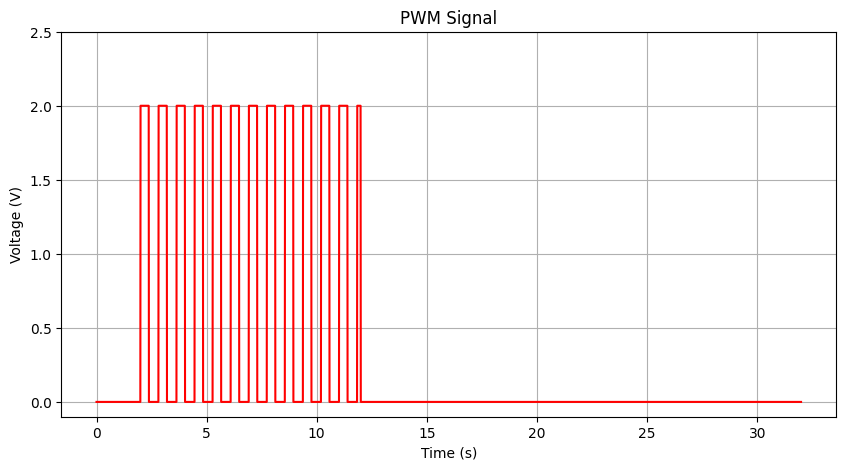

In [ ]:
def print_pwm_signal():
  plt_time = np.arange(0, len(pwmSignal) * timestep, timestep)
  plt_voltage = [onVoltage if x == 1 else offVoltage for x in pwmSignal]

  plt.figure(figsize=(10, 5))
  plt.ylim(-0.1, onVoltage + 0.5)
  plt.plot(plt_time, plt_voltage, color="red")
  plt.xlabel("Time (s)")
  plt.ylabel("Voltage (V)")
  plt.title("PWM Signal")
  plt.grid(True)
  plt.show()

print_pwm_signal()

In [ ]:
# Generate wires

# Set to True to use test network.
useTestNetwork = True

if not useTestNetwork:
  for i in range(n):
      #randHalfLen = np.random.gamma(10, (halflen*0.6)/10)
      randHalfLen = halflen

      theta = random.uniform(0, 2*np.pi)
      #m = math.tan(theta)

      c = random.uniform(0,1)

      x = random.uniform(0+randHalfLen+margin, vwidth-randHalfLen-margin)
      y = random.uniform(0+randHalfLen+margin, vheight-randHalfLen-margin)

      dx = randHalfLen*math.cos(theta)
      dy = randHalfLen*math.sin(theta)

      m = ((y+dy) - (y-dy))/((x+dx) - (x-dx))
      c = (y-dy) - m*(x-dx)

      matW[i] = [
          theta,
          m,
          c, # bias (constant c in y=mx+c)
          [x, y], # midpoint
          [x-dx, y-dy], # endpoint 1
          [x+dx, y+dy], # endpoint 2
          0 # P = IV
      ]
else:
  raw = """
  [
          [6.197440915565757, -0.08595514522859592, 746.4162444940531,
          [507.7323081184253, 702.7740402124837],
          [308.4670678532522, 719.9019128784877],
          [706.9975483835983, 685.6461675464797], 0],

          [5.832173897211155, -0.48430309037742797, 700.5034159054129,
          [585.0909958442003, 417.14203846605983],
          [405.08965316532857, 504.3172449975238],
          [765.0923385230719, 329.96683193459586], 0],

          [3.7671824805649723, 0.722381678305219, 456.95201240882994,
          [324.4533865442059, 691.3311943124454],
          [486.5769610052443, 808.4462941244515],
          [162.3298120831675, 574.2160945004393], 0],

          [4.261846388944015, 2.0672926837647263, -747.8699852963412,
          [645.0611698235916, 585.6602516606854],
          [732.1519788135234, 765.7024439087227],
          [557.9703608336598, 405.6180594126481], 0],

          [1.6476890258836814, -12.97949487400327, 6551.694647777918,
          [459.2779730410524, 590.4985509489668],
          [474.64136310157113, 391.0895084111512],
          [443.9145829805337, 789.9075934867824], 0],

          [0.7225165191632054, 0.8815301048371376, 279.93889933656874,
          [341.7530624983201, 581.2045123491257],
          [191.72426326089254, 448.9496092287663],
          [491.78186173574767, 713.4594154694851], 0],

          [3.283391704073319, 0.14275714005218826, 577.4223735638184,
          [276.1925126876021, 616.8508267789282],
          [474.185182444135, 645.1156940646682],
          [78.19984293106921, 588.5859594931882], 0],

          [0.5980677512927861, 0.6813039251457697, -11.683464778286123,
          [498.2085658042258, 327.7479866453774],
          [332.9235451661975, 215.1386533168892],
          [663.4935864422541, 440.35731997386563], 0],

          [4.084596655575001, 1.3779060891957067, -219.04345008135942,
          [683.2813500357711, 722.4540827667927],
          [800.753242318387, 884.3193184523514],
          [565.8094577531551, 560.588847081234], 0],

          [5.195900222467021, -1.9044646284582067, 1078.8640058398119,
          [388.2766002684451, 339.40495457055187],
          [295.29844497882357, 516.4785625389304],
          [481.2547555580667, 162.3313466021733], 0],

          [5.9869688268451995, -0.3051955155243185, 623.9675805697073,
          [578.53104144398, 447.4025011293909],
          [387.24149041424926, 505.783214270325],
          [769.8205924737108, 389.02178798845677], 0],

          [2.7235722029078606, -0.44420031529022763, 878.132964758902,
          [353.5125902646557, 721.1025607042768],
          [536.2914568027098, 639.9121305596827],
          [170.73372372660162, 802.2929908488709], 0],

          [3.265113413975372, 0.12415281907692624, 545.3615358538215,
          [405.68041629207005, 595.727903180783],
          [604.1566173777157, 620.3692830652448],
          [207.2042152064244, 571.0865232963212], 0],

          [0.8829172477619881, 1.2168756094977067, -255.78736135248997,
          [517.8332029792564, 374.35123314104237],
          [390.85320299217034, 219.83236826273819],
          [644.8132029663425, 528.8700980193465], 0],

          [5.49196628490659, -1.011710012335062, 835.4368673620229,
          [410.9630968481896, 419.66138758048567],
          [270.36732555948186, 561.9035370852417],
          [551.5588681368973, 277.4192380757296], 0],

          [2.2680611338281262, -1.1938538856980245, 1241.3039190863585,
          [532.833962177308, 605.1780229091053],
          [661.2586199952425, 451.8577461537249],
          [404.40930435937344, 758.4982996644856], 0]
  ]
  """

  # Step 1: Clean the string to replace `list([...])` with `[...]`
  cleaned = raw.replace('list(', '')
  cleaned = cleaned.replace(')', '')
  cleaned = cleaned.replace('\n', '').replace(' ', '')
  cleaned = cleaned.replace('),', ',').replace(')\n', ']\n')

  # Step 3: Evaluate as a Python object safely
  data = ast.literal_eval(cleaned)

  # Step 4: Convert to NumPy array
  matW = np.array(data, dtype=object)

#matW

In [ ]:
# Create system of equations
matM = np.empty((n, 1)) # Matrix of slopes
matC = np.empty((n, 1)) # Matrix of y-intercepts

# Fill matM and matC
for i in range(n):
    matM[i] = matW[i][1]
    matC[i] = matW[i][2]

# Find intersections
# (node at matA[i][j] is the location of an atomic bridge)
for i in range(n):
    for j in range(i,n):
        if i != j:
            if matM[i] != matM[j]:

                x1 = matW[i][4][0]
                y1 = matW[i][4][1]
                x2 = matW[j][4][0]
                y2 = matW[j][4][1]

                # y = mx + c
                # y1 = matM[i]*x + matC[i]
                # y2 = matM[j]*x + matC[j]
                # find the intersection of y1 = y2, solve for x
                xf = (matC[i]-matC[j])/(matM[j]-matM[i])
                yf = matM[i]*xf[0] + matC[i]

                """
                print(x1,y1, x2,y2)
                print(xf, yf)
                print(abs(xf-x1), abs(yf-y1))
                print(abs(x2-x1), abs(y2-y1))
                print(abs(matM[i]*(xf[0] - matW[i][3][0])))
                print("")
                """

                # Check Intersection
                # 1. x in bounds, y in bounds
                # 2. Intersection is between a and b for wire 1
                # 3. Intersection is between a and b for wire 2
                if xf[0] >= 0 and xf[0] <= vwidth and yf[0] >= 0 and yf[0] <= vheight and \
                  (abs(xf[0] - matW[i][3][0]) <= abs(matW[i][4][0] - matW[i][3][0])) and \
                  (abs(xf[0] - matW[j][3][0]) <= abs(matW[j][4][0] - matW[j][3][0])):

                  matA[i][j] = 1
                  matA[j][i] = 1
                  matLen[i][j] = 0
                  matG[i][j] = offG
                  matG[j][i] = offG
                  matV[i][j] = 0
                  matIdir[i][j] = 0
                  matImag[i][j] = 0
                  matSoff[i][j] = 1
                  matSoff[j][i] = 1
                  matTsw[i][j] = 0
                  matCoords.append([(xf)[0], (yf)[0], [i,j]])
                  matIntx[i][j] = [(xf)[0], (yf)[0]]
                  matIntx[j][i] = matIntx[i][j]

                else:
                  matA[i][j] = 0
                  matA[j][i] = 0
                  matLen[i][j] = 0
                  matV[i][j] = 0
                  matIdir[i][j] = 0
                  matImag[i][j] = 0
                  matSon[i][j] = 0
                  matSoff[i][j] = 0
                  matTsw[i][j] = 0

print("matCoords",len(matCoords))
print(matCoords)

matCoords 41
[[np.float64(358.09853474170484), np.float64(715.6358329341824), [0, 2]], [np.float64(693.9685296183472), np.float64(686.766078746633), [0, 3]], [np.float64(450.2470636770252), np.float64(707.7151927469455), [0, 4]], [np.float64(482.15447742049884), np.float64(704.9725863647564), [0, 5]], [np.float64(659.5295181480108), np.float64(689.726288979095), [0, 8]], [np.float64(367.6720058561811), np.float64(714.8129438341958), [0, 11]], [np.float64(446.69034859865997), np.float64(708.0209107080432), [0, 15]], [np.float64(567.6343470543239), np.float64(425.59634742263034), [1, 3]], [np.float64(468.275424114748), np.float64(473.7161808588397), [1, 4]], [np.float64(611.0008529452997), np.float64(404.59381460075986), [1, 7]], [np.float64(427.31769104949683), np.float64(493.5521375571946), [1, 10]], [np.float64(562.1342292424035), np.float64(428.26007147638336), [1, 13]], [np.float64(444.8107974190037), np.float64(778.2751827766526), [2, 4]], [np.float64(207.84206534471804), np.float6

In [ ]:
# Get endpoints closest to corners
topDistance = 0
botDistance = 0
for i in range(n):
    # Get the two endpoints
    x1 = matW[i][4][0]
    y1 = matW[i][4][1]
    x2 = matW[i][5][0]
    y2 = matW[i][5][1]

    # Calculate the distance from the top left corner
    d1 = math.sqrt((x1-topCorner[0])**2 + (y1-topCorner[1])**2)
    d2 = math.sqrt((x2-topCorner[0])**2 + (y2-topCorner[1])**2)

    # Calculate the distance from the bottom right corner
    d3 = math.sqrt((x1-bottomCorner[0])**2 + (y1-bottomCorner[1])**2)
    d4 = math.sqrt((x2-bottomCorner[0])**2 + (y2-bottomCorner[1])**2)

    # If the distance is less than the current closest distance, update the closest distance
    if d1 < topDistance:
        topDistance = d1
        wireVcc = i
        nodeVcc = 4

    if d2 < topDistance:
        topDistance = d2
        wireVcc = i
        nodeVcc = 5

    if d3 < botDistance:
        botDistance = d3
        wireGnd = i
        nodeGnd = 4

    if d4 < botDistance:
        botDistance = d4
        wireGnd = i
        nodeGnd = 5

    if i == 0:
        topDistance = d1
        botDistance = d1

if wireGnd == wireVcc:
  if wireGnd + 1 < n:
    wireGnd = wireGnd + 1
  else:
    wireGnd = wireGnd - 1

print(wireVcc, nodeVcc, matW[wireVcc][nodeVcc])
print(wireGnd, nodeGnd, matW[wireGnd][nodeGnd])

11 5 [170.73372372660162, 802.2929908488709]
1 5 [765.0923385230719, 329.96683193459586]


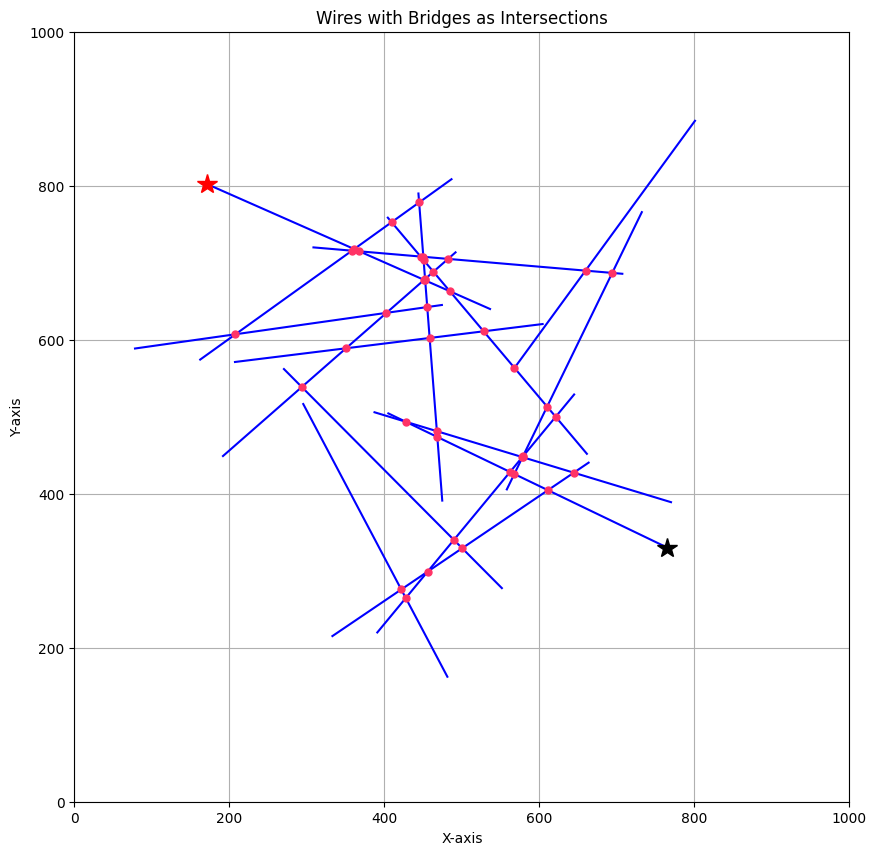

In [ ]:
plt.figure(figsize=(10, 10))

# Plot lines
for i in range(n):
    x_values = [matW[i][4][0], matW[i][5][0]]
    y_values = [matW[i][4][1], matW[i][5][1]]
    plt.plot(x_values, y_values, 'b-')  # 'b-' for blue lines

# Plot intersections/dots
for i in range(len(matCoords)):
  plt.plot(matCoords[i][0], matCoords[i][1], marker='o', color="#ff3366", markersize=5)

# Plot Vcc and GND
plt.plot(matW[wireVcc][nodeVcc][0], matW[wireVcc][nodeVcc][1], marker='*', markersize=15, color='red', label='Vcc')
plt.plot(matW[wireGnd][nodeGnd][0], matW[wireGnd][nodeGnd][1], marker='*', markersize=15, color='black', label='GND')

plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Wires with Bridges as Intersections")
plt.xlim(0, vwidth)
plt.ylim(0, vheight)
plt.grid(True)
plt.show()

In [ ]:
def getVoltages(inputVoltage):
  # Save a copy of the voltages
  #lastV = vecV

  # Set system of equations to solve for voltages
  A = np.zeros((n,n))
  for i in range(n):
    for j in range(i+1,n):
      if matA[i][j] == 1:
        Gij = matG[i][j]
        if j == i+1:
          Gij = -Gij
        A[i][i] = A[i][i] - Gij
        A[i][j] = A[i][j] - Gij

  A1 = np.zeros((n,n))
  A2 = np.zeros((n,n))
  ones = np.ones(n)

  A1[:,wireVcc] = A[:,wireVcc]
  A2[:,wireGnd] = A[:,wireGnd]

  #print(A)
  #print(A1)
  #print(A2)

  # Ax = 0
  # A is conductances, x is voltages at node, equivalent to 0 to comply with KCL
  # A'x = b, we've removed the source and ground wires from A and moved them to b

  #b = -1 * (onVoltage*A[:, wireVcc] + offVoltage*A[:, wireGnd]) # ATTENTION: this is wrong
  b = -1 * (onVoltage*np.dot(ones,A1) + offVoltage*np.dot(ones,A2))

  #Aprime = np.delete(A, [wireVcc, wireGnd], axis=1)
  Aprime = A - A1 - A2

  # inverse of A
  pinvA = np.linalg.pinv(Aprime)

  #print("pinvA\n",pinvA)
  #print("b\n",b)

  x = np.dot(pinvA, b)
  v = np.zeros((n))

  # Reshape voltages vector
  first = 0
  second = 0
  if wireVcc < wireGnd:
    first = wireVcc
    second = wireGnd
  else:
    first = wireGnd
    second = wireVcc

  v[wireVcc] = inputVoltage
  v[wireGnd] = 0

  j = 0
  for i in range(n):
    if i != first and i != second:
      v[i] = x[j]
      j += 1

  #print(x)
  #print(v)

  return v

"""
print("original voltages",vecV)
vecV = getVoltages(onVoltage)
print("updated voltages",vecV)
"""

'\nprint("original voltages",vecV)\nvecV = getVoltages(onVoltage)\nprint("updated voltages",vecV)\n'

In [ ]:
def getCurrents(vecV):
  # Set system of equations to solve for conductances

  # Find difference between voltages. To be multiplied by G later.
  for i in range(n):
    for j in range(i+1,n):
      if matA[i][j] == 1:
        matV[i][j] = vecV[i] - vecV[j]
        matV[j][i] = -matV[i][j]

  return matV * matG

matI = getCurrents(vecV)
matIdir = np.sign(matI)
matImag = np.abs(matI)

"""
print(matV)
print(matG)
print(matI)
print(matIdir)
print(matImag)
"""

'\nprint(matV)\nprint(matG)\nprint(matI)\nprint(matIdir)\nprint(matImag)\n'

In [ ]:
def updatePowerLoss(vecV):
  for i in range(n):
    inputPower = 0
    for j in range(i,n):
      if matIdir[i][j] == -1:
        inputPower += -1*(vecV[i] - vecV[j]) * matImag[i][j]
    matW[i][6] = inputPower

#updatePowerLoss()
#print(matW)

def calcPowerLoss():
  for i in range(n):
    for j in range(i,n):
      if matA[i][j] == 1:
        matP[i][j] = abs(matV[i][j] * matImag[i][j])
        matP[j][i] = matP[i][j]

#calcPowerLoss()
#print(matP)

In [ ]:
def getGth(v_in):
  """
  global matImag

  i_out = 0
  for j in range(n):
    i_out += matImag[wireVcc][j]
  #return i_out/v_in # I think v_in maybe heavily biasing the conductance
  return i_out
  """
  global matSon, matSoff

  sumOn = 0
  sumOff = 0
  for i in range(n):
    for j in range(i+1,n):
      if matA[i][j] == 1:
        if matSon[i][j] == 1: sumOn += matImag[i][j]
        if matSoff[i][j] == 1: sumOff += matImag[i][j]

  return sumOn*onG + sumOff*offG

#g_th = getGth(onVoltage)
#history.append(g_th)

#print(history)

In [ ]:
def updateLengths(lastV,vecV):
  """
  print('\nupdating lengths')
  print("matA\n",matA)
  print("matI\n",matI)
  print("matV\n",matV)
  print("vecV\n",vecV)
  print("lastV\n",lastV)
  """

  # dLij/dt = A*exp(-D*Iij)
  # --> dLij = Lij2 - Lij1 = exp(-D*Iij)*dt
  # --> Lij2 = exp(-D*Iij)*dt + Lij1
  # A is the scaling constant. Set to 1.
  # D is the direction constant. -1 for growing, +1 for shrinking.
  for i in range(n):
    for j in range(i+1,n):
      if matA[i][j] == 1:

        #print("==INDEX IS",j)

        # IMPORTANT: There's a problem detecting which way the bridge is growing.
        # Set direction (shrink/grow) under standard conditions
        if lastV[j] > vecV[j]: direction = 1
        elif lastV[j] < vecV[j]: direction = -1
        else: direction = 0

        #if abs(matV[i][j]) < threshV: direction = 1 # Shrink if below threshold voltage
        if abs(vecV[j]) < threshV: direction = 1 # Shrink if below threshold voltage

        # Should the bridge only start shrinking after a number of timesteps?
        #  NO! According to Hasegawa2011, Figure 2, the bridge will immediately
        #  collapse when current subsides at a voltage.

        #matLen[i][j] = math.exp(-direction*matImag[i][j]) * (timestep * 1e-10) + matLen[i][j]
        matLen[i][j] = math.exp(-direction*matImag[i][j]) * (timestep) + matLen[i][j]
        matLen[j][i] = matLen[i][j]

        """
        if direction == 1: print("SHRINKING")
        elif direction == -1: print("GROWING")
        else: print("STANDARD")

        print("vecV[j]",vecV[j])
        print("lastV[j]",lastV[j])
        print("matLen update",gapDist-matLen[i][j],gapDist,matLen[i][j])
        #print("matV[i][j]",matV[i][j])
        #print("matG[i][j]",matG[i][j])
        #print("matI[i][j]",matI[i][j])

        #print("voltage",vecV[i],lastV[i])
        """

        if (gapDist - matLen[i][j] <= 0) and (vecV[j] - threshV >= 0): # Switch on bridge
          #print("turn on",i,j)
          matG[i][j] = onG
          matG[j][i] = onG
          matSon[i][j] = 1
          matSon[j][i] = 1
          matSoff[i][j] = 0
          matSoff[j][i] = 0
          #matTsw[i][j] = 0
          #matTsw[j][i] = 0
          matLen[i][j] = gapDist # Constrain maximum length
          matLen[j][i] = gapDist

        elif gapDist - matLen[i][j] > 0: # Switch off bridge
        #else: # Switch off bridge
          #print("turn off",i,j)
          matG[i][j] = offG
          matG[j][i] = offG
          matSon[i][j] = 0
          matSon[j][i] = 0
          matSoff[i][j] = 1
          matSoff[j][i] = 1

        if matLen[i][j] <= 0: # Constrain minimum length
          #print("constrain",i,j)
          matLen[i][j] = 0
          matG[i][j] = offG
          matG[j][i] = offG
          matSon[i][j] = 0
          matSon[j][i] = 0
          matSoff[i][j] = 1
          matSoff[j][i] = 1

        #print("cur length",gapDist - matLen[i][j], direction)

  #print(direction, matImag[i][j])
  #print("updated matLen\n", matLen)

"""
print("gapDist",gapDist)
print("original matLen\n", matLen)
print("original matSon\n", matSon)
print("original matSoff\n", matSoff)
updateLengths()
print("updated matLen\n",matLen)
print("updated matSon\n",matSon)
print("original matSoff\n", matSoff)
"""
#updateLengths()
#print(matG)

'\nprint("gapDist",gapDist)\nprint("original matLen\n", matLen)\nprint("original matSon\n", matSon)\nprint("original matSoff\n", matSoff)\nupdateLengths()\nprint("updated matLen\n",matLen)\nprint("updated matSon\n",matSon)\nprint("original matSoff\n", matSoff)\n'

In [ ]:
def powerSpectralDensity():
  # P = lim(T->inf) (1/T) integral(x(t)^2, t0-T/2 -> t0+T/2)*dt
  # x(t) is thevenin conductance at any time t
  sum = 0
  #sample_time = len(history) * timestep
  sample_time = int(pwmMaxTime/period)
  for t in range(len(history)):
    sum += history[t]*history[t]

  return sum/sample_time

print(powerSpectralDensity())

0.0


In [ ]:
def print_results():
  print("wireVcc",wireVcc)
  print("wireGnd",wireGnd)
  print("matA\n",matA)
  print("matLen\n",matLen)
  print("G\n",matG)
  print("Son\n",matSon)
  print("Soff\n",matSoff)
  print("Idir\n",matIdir)
  print("Imag\n",matImag)
  print("vecV\n",vecV)
  print("matV\n",matV)

#print_results()

In [ ]:
def get_largest_current():
  largest_current = 0
  for i in range(n):
    for j in range(i+1,n):
      if matImag[i][j] > largest_current:
        #print("new largest current!")
        largest_current = matImag[i][j]

  return largest_current

largest_current = get_largest_current()
print("largest_current",largest_current)

largest_current 0


In [ ]:
#from re import A

def paintPlot():
  #print_results()

  plt.figure(figsize=(10, 10))
  ax=plt.axes()
  ax.set_facecolor('#333333')

  x_source = matW[wireVcc][nodeVcc][0]
  y_source = matW[wireVcc][nodeVcc][1]

  x_sink = matW[wireGnd][nodeGnd][0]
  y_sink = matW[wireGnd][nodeGnd][1]

  # Get bridges (intersections) to draw
  x_coords = []
  y_coords = []
  z_coords = []

  x_coords_on = []
  y_coords_on = []

  x_coords_off = []
  y_coords_off = []

  #print("matP\n",matP)
  #print("matSon\n",matSon)

  i = 0
  for i in range(len(matCoords)):
    x_coords.append(matCoords[i][0])
    y_coords.append(matCoords[i][1])

    ith = matCoords[i][2][0]
    jth = matCoords[i][2][1]

    if matSoff[ith][jth] == 1:
      z_coords.append(0)
      x_coords_on.append(0-margin) # place outside of graph
      y_coords_on.append(0-margin)
      x_coords_off.append(matCoords[i][0])
      y_coords_off.append(matCoords[i][1])
    else:
      power = abs(matP[ith][jth])
      if power == 0:
        power = 0.00000000001
        #print("power",power)
      z_coords.append(abs(math.log(power)))
      #z_coords.append(math.log(power)) # to reverse the color map
      x_coords_on.append(matCoords[i][0])
      y_coords_on.append(matCoords[i][1])
      x_coords_off.append(0-margin)
      y_coords_off.append(0-margin)

  #print("index",i)

  # Plot Vcc and GND
  plt.plot(matW[wireVcc][nodeVcc][0], matW[wireVcc][nodeVcc][1], marker='*', markersize=15, color='#06fc03', label='Vcc')
  plt.plot(matW[wireGnd][nodeGnd][0], matW[wireGnd][nodeGnd][1], marker='*', markersize=15, color='#ed0701', label='GND')

  # Create wire lists. Calculate distance along source to sink vector
  x_values = []
  y_values = []
  z_wires = []

  x_values_sorted = []
  y_values_sorted = []
  z_wires_sorted = []

  v_vec = [x_sink - x_source, y_sink - y_source]
  v_norm = v_vec / np.dot(v_vec, v_vec)

  for i in range(n):
      x_center = matW[i][3][0]
      y_center = matW[i][3][1]

      w_vec = [x_center - x_source, y_center - y_source]

      # w projected onto v = w (dot) vhat = w (dot) v/|v| = w (dot) vnorm
      z_wires.append(np.dot(w_vec, v_norm))

      x_values.append([matW[i][4][0], matW[i][5][0]])
      y_values.append([matW[i][4][1], matW[i][5][1]])

  # sort x_values and y_values by z_wires
  for i in range(n):
    for j in range(i+1,n):
      if z_wires[i] < z_wires[j]:
        temp_x = x_values[i]
        temp_y = y_values[i]
        x_values[i] = x_values[j]
        y_values[i] = y_values[j]
        x_values[j] = temp_x
        y_values[j] = temp_y
        temp_z = z_wires[i]
        z_wires[i] = z_wires[j]
        z_wires[j] = temp_z

  #cust_colormap = mcol.LinearSegmentedColormap.from_list("MyCmapName",["r","b"])
  wire_map = plt.get_cmap('RdYlGn', n)

  # Plot lines
  for i in range(n):
    plt.plot(x_values[i], y_values[i], c=wire_map(i),
            alpha=0.5, linewidth=1, zorder=0)

  #print("z_coords\n",z_coords)
  #print("x_coords\n",x_coords)
  #print("y_coords\n",y_coords)
  #z_coords = [1,2,3]

  # reverse the order of z_coords
  #z_coords.reverse()

  plt.plot(markersize=20)
  #plt.scatter(x=x_coords_off, y=y_coords_off, color="#440154", zorder=1, marker='s')
  #plt.scatter(x=x_coords_off, y=y_coords_off, color="#440154", zorder=1, marker='*')
  plt.scatter(x=x_coords_off, y=y_coords_off, color="#000000", zorder=1, marker='s')

  # scatterplot
  plt.plot(markersize=20)
  plt.scatter(x=x_coords_on, y=y_coords_on, c=z_coords, cmap="viridis", zorder=1)
  #plt.scatter(x=x_coords_on, y=y_coords_on, color="cyan", zorder=1, marker='s')
  plt.colorbar(label="Power (logarithmic scale)", orientation="vertical")

  # draw currents
  #print(matW)
  #print(matI)
  #print(matA)
  #print("=======")
  #print()

  def drawArrow(p1,p2,color,current):
    # shorten arrow
    #print("p1 and p2",p1,p2)

    arr_len = math.sqrt((p2[0]-p1[0])**2 + (p2[1]-p1[1])**2)

    try:
      scalar = abs((current - largest_current) / ((current + largest_current) / 2)) / 100
    except:
      scalar = 0

    if scalar > 1: scalar = 0.1

    margin = 0.35 + scalar
    delta = (1-margin) * arr_len
    arr_m = (p2[1]-p1[1]) / (p2[0]-p1[0])
    p3x = p1[0] + margin*(p2[0]-p1[0])
    p4x = p2[0] - margin*(p2[0]-p1[0])
    p3 = [p3x, p1[1] + arr_m*margin*(p2[0]-p1[0])]
    p4 = [p4x, p2[1] - arr_m*margin*(p2[0]-p1[0])]

    """
    if color == 'cyan':
      print('p3,p4',p3,p4)
      print('arr_m',arr_m)
      print('largest_current',largest_current)
      print('current',current)
      print('scalar',scalar)
      print('margin',margin)
    """

    plt.arrow(p3[0], p3[1], p4[0]-p3[0], p4[1]-p3[1],
      head_width=5, head_length=5, fc=color, ec=color,
      linewidth=0.8, alpha=0.8, length_includes_head=True)

  isTesting = True

  # wire by wire
  for i in range(n):
    nearest = []

    # intersection by intersection
    for j in range(n):
      if i == j or matA[i][j] == 0: continue

      # distance to closest point on left or right
      dist = np.linalg.norm(np.array(matIntx[i][j]) - np.array(matW[i][4]))
      nearest.append([dist, j])

    if len(nearest) == 0: continue

    if i == wireVcc or i == wireGnd:
      nearest.sort(key=lambda x: x[0])

      if i == wireVcc: node = nodeVcc
      else: node = nodeGnd

      # check which side the source/sink is on
      near = np.linalg.norm(np.array(matIntx[i][nearest[0][1]]) - np.array(matW[i][node]))
      far = np.linalg.norm(np.array(matIntx[i][nearest[len(nearest)-1][1]]) - np.array(matW[i][node]))

      # draw first/final arrow on the source/sink wire
      if i == wireVcc:
        if near < far:
          #print('dees one')
          if isTesting: drawArrow(matW[i][node],matIntx[i][nearest[0][1]],'yellow',largest_current)
          if not isTesting: drawArrow(matW[i][node],matIntx[i][nearest[0][1]],'white',largest_current)
        else:
          #print('dat one')
          if isTesting: drawArrow(matW[i][node],matIntx[i][nearest[len(nearest)-1][1]],'yellow',largest_current)
          if not isTesting: drawArrow(matW[i][node],matIntx[i][nearest[len(nearest)-1][1]],'white',largest_current)

      elif i == wireGnd:
        if near > far:
          #print('this one')
          if isTesting: drawArrow(matIntx[i][nearest[len(nearest)-1][1]],matW[i][node],'magenta',largest_current)
          if not isTesting: drawArrow(matIntx[i][nearest[len(nearest)-1][1]],matW[i][node],'white',largest_current)
        else:
          #print('that one')
          if isTesting: drawArrow(matIntx[i][nearest[0][1]],matW[i][node],'magenta',largest_current)
          if not isTesting: drawArrow(matIntx[i][nearest[0][1]],matW[i][node],'white',largest_current)

      # draw intermediate arrows on the source/sink wire
      for k in range(len(nearest)-1):
        p1 = matIntx[i][nearest[k][1]]
        p2 = matIntx[i][nearest[k+1][1]]

        if i == wireVcc:
          if near < far:
            if isTesting: drawArrow(p1,p2,'yellow',largest_current)
            if not isTesting: drawArrow(p1,p2,'white',largest_current)
          else:
            if isTesting: drawArrow(p2,p1,'yellow',largest_current)
            if not isTesting: drawArrow(p2,p1,'white',largest_current)

        elif i == wireGnd:
          if near > far:
            if isTesting: drawArrow(p1,p2,'magenta',largest_current)
            if not isTesting: drawArrow(p1,p2,'white',largest_current)
          else:
            if isTesting: drawArrow(p2,p1,'magenta',largest_current)
            if not isTesting: drawArrow(p2,p1,'white',largest_current)

    # since there is no current inside of a node (each wire is a node),
    #  separate branches, such that intersections become intermediate nodes.
    if len(nearest) > 0:

      sum = 0
      for j in range(n): sum += matA[i][j]

      if i != wireGnd and i != wireVcc and sum > 0:

        nearest.sort(key=lambda x: x[0])

        # iterate through points
        # IMPORTANT matA should be replaced with matSon once switches are enabled
        for j in range(len(nearest)):
          lhs = 0
          lon = 0
          for k1 in range(0,j):
            lhs += matI[i][nearest[k1][1]]
            lon += matSon[i][nearest[k1][1]]

          rhs = 0
          ron = 0
          for k2 in range(j+1, len(nearest)):
            rhs += matI[i][nearest[k2][1]]
            ron += matSon[i][nearest[k2][1]]

          if j < len(nearest)-1:
            b = matIntx[i][nearest[j][1]]
            a = matIntx[i][nearest[j+1][1]]

          direction = 0
          if lon > 0 and ron > 0:
            if lhs > rhs:
              #print("cyan a b",a,b)
              if isTesting: drawArrow(a,b,'cyan',matI[i][nearest[j][1]])
              if not isTesting: drawArrow(a,b,'white',matI[i][nearest[j][1]])

            elif lhs < rhs:
              #if isTesting: drawArrow(b,a,'red',matI[i][nearest[j+1][1]])
              if isTesting: drawArrow(a,b,'red',matI[i][nearest[j+1][1]]) # reverse direction
              if not isTesting: drawArrow(b,a,'white',matI[i][nearest[j+1][1]])

            else:
              #print("go",matI[i])
              if matI[i][nearest[j][1]] > matI[i][nearest[j+1][1]]:
                if isTesting: drawArrow(a,b,'orange',matI[i][nearest[j][1]])
                if not isTesting: drawArrow(a,b,'white',matI[i][nearest[j][1]])
              elif matI[i][nearest[j][1]] < matI[i][nearest[j+1][1]]:
                if isTesting: drawArrow(b,a,'white',matI[i][nearest[j+1][1]])
                if not isTesting: drawArrow(b,a,'white',matI[i][nearest[j+1][1]])

          else:
            #print('lon ron j',lon,ron,j)
            if(lon == 0 and ron == 0):
              #print("skip")
              continue

            if (lon > 0 and ron == 0) and (j != len(nearest)-1):
              if isTesting: drawArrow(b,a,'orange',matI[i][nearest[j][1]])
              if not isTesting: drawArrow(b,a,'orange',matI[i][nearest[j][1]])

            # this just doesn't work because the arrows are an optical illusion.
            elif (lon == 0 and ron > 0) and (j != 0):
              if isTesting: drawArrow(b,a,'white',matI[i][nearest[j+1][1]])
              if not isTesting: drawArrow(b,a,'white',matI[i][nearest[j+1][1]])


  plt.xlabel("x (μm)")
  plt.ylabel("y (μm)")
  plt.title("Snapshot visualization of Ag nanowire atomic switch network")
  plt.xlim(0, vwidth)
  plt.ylim(0, vheight)
  #plt.grid(True)

  """
  print("gapDist",gapDist)
  print("matLen",matLen)
  print("matP\n",matP)
  print("matSon\n",matSon)
  print("matSoff\n",matSoff)
  """

  plt.show()

#paintPlot()

In [ ]:
def run_simulation():
  #print("signal length",len(pwmSignal))
  for t in range(len(pwmSignal)):
    if pwmSignal[t] == 1: v_in = onVoltage
    else: v_in = offVoltage

    voltages = getVoltages(v_in)
    if t == 0:
      #print("TIME IS 0")
      old_voltages = voltages
    #getVoltages(v_in)

    global matI, matIdir, matImag

    #tempI = getCurrents(vecV)
    tempI = getCurrents(voltages)
    matI = tempI
    matIdir = np.sign(tempI)
    matImag = np.abs(tempI)

    """
    print("***********")
    print("time =",t)
    print("v_in",v_in)
    print("voltages\n",old_voltages,voltages)
    print("***********")
    print("***********")
    """

    updateLengths(old_voltages,voltages)
    old_voltages = voltages
    calcPowerLoss()

    g_th = getGth(v_in)
    history.append(g_th)

    #print("lengths",matLen)
    #print("matSOff",matSoff)
    #print("matSOn",matSon)
    #print()
    if t == 30/timestep:
      paintPlot()

  #print("history")
  #print(history)


  return powerSpectralDensity()

"""
psd_history = []
for i in range(10):
  #pwmSignal = generatePWMSignal(timestep,30) # 20250705,9:38am - deprecating waitTime
  pwmSignal = generatePWMSignal(timestep)
  psd_history.append(run_simulation())

print(psd_history)
"""

"""
history = []
print("original matSon\n",matSon)
print("original matSoff\n",matSoff)
psd = run_simulation()
print("updated matSon\n",matSon)
print("updated matSoff\n",matSoff)
print("PSD =",psd,"S^2/s")
print("f =",frequency,"Hz")
print("1/f =",1/frequency,"s")
"""

#print()
#print(history)

#print()
#print(print_results())

'\nhistory = []\nprint("original matSon\n",matSon)\nprint("original matSoff\n",matSoff)\npsd = run_simulation()\nprint("updated matSon\n",matSon)\nprint("updated matSoff\n",matSoff)\nprint("PSD =",psd,"S^2/s")\nprint("f =",frequency,"Hz")\nprint("1/f =",1/frequency,"s")\n'

In [ ]:
# prompt: plot a graph of values in history versus timestep

def print_conductance():
  # Plot the history of Thevenin conductances
  plt.figure(figsize=(10, 5))
  plt.plot(np.arange(len(history)), history, color="black")
  plt.xlabel("Timestep")
  plt.ylabel("Thevenin Conductance (S)")
  plt.title("Thevenin Conductance over Time")
  plt.grid(True)
  plt.show()

#print_conductance()

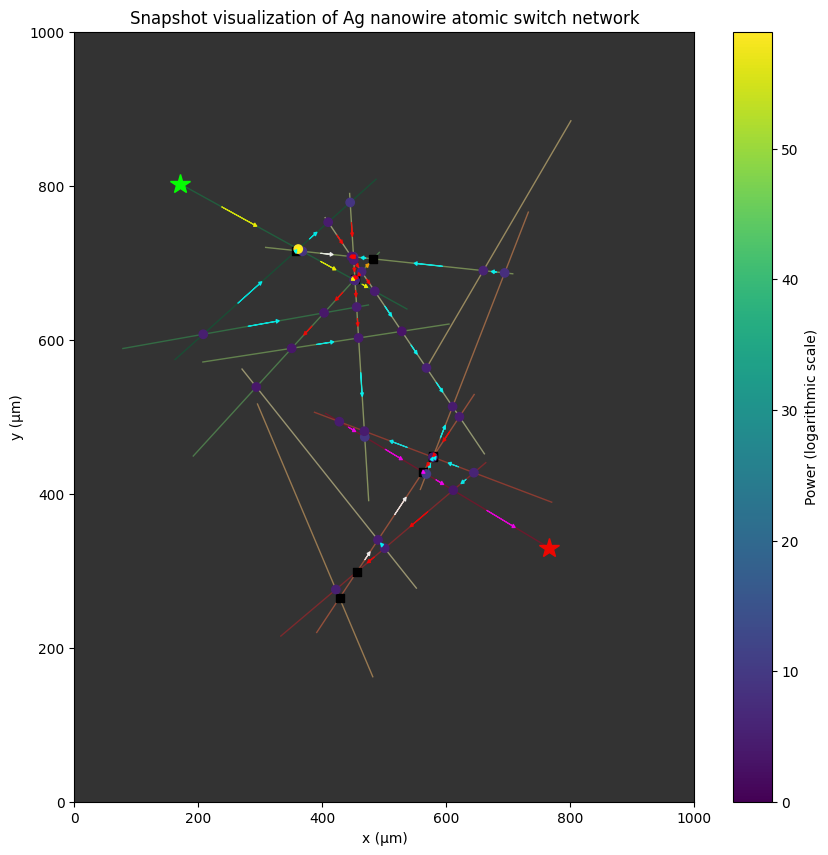

PSD = 3.1284497522629755e-10 S^2/s
f = 1.2195121951219512 Hz
1/f = 0.8200000000000001 s


In [ ]:
#print_results()

#print("original matSon\n",matSon)
#print("original matSoff\n",matSoff)
psd = run_simulation()
#print("updated matSon\n",matSon)
#print("updated matSoff\n",matSoff)
print("PSD =",psd,"S^2/s")
print("f =",frequency,"Hz")
print("1/f =",1/frequency,"s")

#paintPlot()

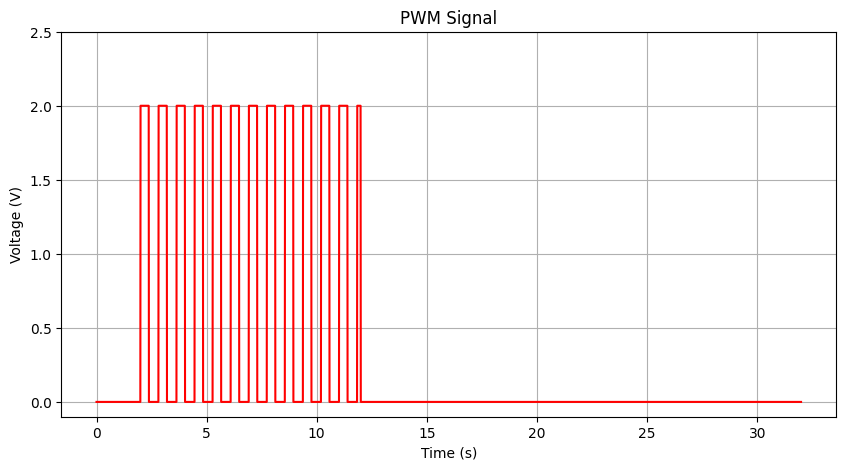

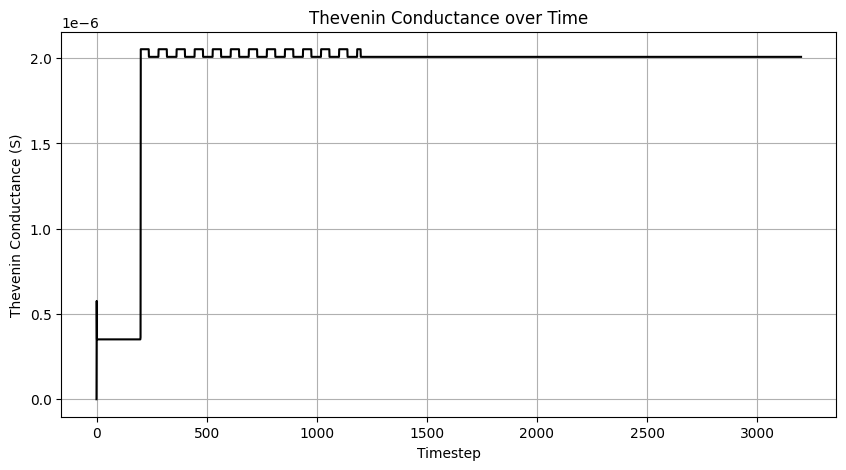

In [ ]:
print_pwm_signal()
print_conductance()

notes
we're having problems with arrays not being accessed at the proper time
currently trying to pass vecV and lastV around.... but it's going arwy
i think the most recent errors on painting come from having entries with 0 power (again, coming from vecV being all 0's)


---


lastV and vecV (used for tracking previous and current active node voltages) are overlapping. this means that lastV is getting updated before calculations have a chance to be processed.


---


20250630, 9:52pm - okay, i think vaguely remember that vecV and lastV do not match the dimensions of matV. i think vec/lastV just stores intersection node voltages whereas matV contains all potential intersections. vecV and lastV need to have matrix versions.

20250630, 11:17pm - looks like i solved the vecV, matV issue by changing getCurrents(vecV) to getCurrents(voltages). next up is solving the matI as all zeroes problem.

---

20250702, 11:08pm - adding in random length functionality. probably need to remove print() statements for run_simulation(). finally, trying to figure out why all points flip.

maybe i need to introduce a save function for holding network configurations.

---

20250703, 11:41pm - sometimes the paint looks correct-ish. sometimes it looks completely off base. i think the next thing to do is to confirm that the paint is for the last timestep. once that is confirmed then we can get results.

---

20250704, 5:05pm - okay i can see conductances now. i figured out that calculating the conductance based on current and voltage is unnecessary since we can just count which switches are on and off. next, there are 2 major problems:
1. not every generation is successful, so just finding a working graph is annoying. sometimes i get like 10 failed graphs in a row. this is an absolute must to fix.
2. somehow the network is turned off by the end of the pwm signal... which doesnt make sense because the pwm just turns on and stays on for 3 seconds. this is probably the core issue of why this isnt working.

---

20250704, 11:27pm - solved #1. now for #2. i think there's some reason why the network is behaving badly during the pwm duration.

now is also probably the time to start saving networks. that way we can have a consistent testing environment.

---

20250705, 9:33am - saved a good version of the network to test with. now i need to add some functionality to disable the pwm signal so we can watch conductivity decay. i probably can add an "off time" and subtract it from the total time. that way the pwm signal is only generated during "on time". same can probably be done for "wait time" before initiating the pwm signal.

20250705, 10:19am - okay! we're getting results now! now it's just time to figure out how to get the right results. i think there is some golden ratio for bridge time to build versus timestep that gives the proper conductance curve that im looking for. also, i think before, only a single bridge was building and decaying with the pwm signal.

maybe i should try increasing the fidelity of the simulation such that the timesteps are finer. this would take much longer to simulate, but this is probably more correct (if i remember my time with the inverted pendulum).

20250705, 1:52pm - decreased timestep to 1e-5 from 1e-2. simulation ran too long and colab shut it down. need to rewrite in cpp. new tasks:
1. draw system architecture
2. write all mathematics used down in latex
3. rewrite in cpp
4. 11:31pm - i think line 32 in getVoltages() is wrong. check the PPT for the correct b value. i think it should be something like V0(G0+G1+...+Gn) for power and Vm(Gn) for ground.